## Estrategias de Clasificación en la Liga MX

### Comparativa entre Análisis Discriminante Lineal (LDA) y Árboles de Decisión

#### 1. Introducción

El presente reporte marca una evolución clave en nuestra serie de análisis sobre el rendimiento deportivo en la Liga MX. Tras haber validado que la altitud no es solo un dato geográfico, sino una variable condicionante en el marcador, y haber explorado las probabilidades de éxito mediante modelos logísticos, este estudio se adentra en el terreno de la clasificación avanzada.

El objetivo es poner a prueba dos arquitecturas con filosofías distintas: el **Análisis Discriminante Lineal (LDA) y los Árboles de Decisión.** Mientras que el LDA busca una frontera rígida basada en supuestos de normalidad y el Teorema de Bayes, los Árboles de Decisión segmentan el juego de forma jerárquica, permitiendo capturar comportamientos no lineales que a veces escapan a los modelos tradicionales. En las siguientes secciones, analizaremos cuál de estos "directores técnicos virtuales" **interpreta mejor la complejidad del fútbol mexicano y su factor hipoxia**.

#### 2. Definición del Problema y Partición de los Datos

##### 2.1 Selección de la Variable de Salida

Para este análisis, el enfoque se centra en la capacidad de supervivencia del visitante. Se ha definido una variable binaria denominada "Pontuar", la cual clasifica el resultado en dos escenarios críticos:

* **Clase 1 (Éxito):** El equipo visitante logra sumar puntos (Victoria o Empate).

* **Clase 0 (Derrota):** El equipo visitante se va con las manos vacías.

Esta estructura permite simplificar la volatilidad del marcador y centrar el estudio en el impacto real del hándicap físico sobre la obtención de puntos.

##### 2.2 Estrategia de Partición y Balance de Datos

Dado que el fútbol profesional presenta tendencias naturales (como la histórica ventaja de la localía), el balance entre éxitos y derrotas visitantes no es equitativo. Para evitar que nuestros modelos desarrollen un "sesgo de optimismo" o pesimismo, hemos implementado una **división estratificada de los datos.**

Se ha reservado un porcentaje del dataset para el entrenamiento y el resto para una fase de prueba rigurosa. El uso de la estratificación es innegociable en este contexto: garantiza que la proporción de partidos jugados en condiciones críticas de altitud y sus respectivos resultados se mantenga constante en ambos grupos. Sin este rigor en la partición, las métricas de desempeño podrían ser espejismos estadísticos en lugar de realidades competitivas.

#### 3. Modelo basado en Análisis Discriminante Lineal (LDA)

##### 3.1 Evaluación de Supuestos y Construcción

El modelo LDA se fundamenta en la aplicación del Teorema de Bayes para calcular la probabilidad a posteriori de que un equipo visitante puntúe. Para que este modelo sea robusto, la teoría sugiere que las variables predictoras deben aproximarse a una distribución normal.

Al analizar el diferencial de altitud ($\Delta \text{Altitud}$), observamos que la distribución de nuestros datos permite el uso de esta técnica paramétrica. El modelo fue entrenado para encontrar la combinación lineal que maximize la separación entre quienes logran sumar puntos y quienes regresan con una derrota.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Carga de datos y preparación
df = pd.read_csv('matches_LigaMX20212025.csv', sep=';', encoding='latin1')

altitudes = {
    'Querétaro': 1820, 'Pachuca': 2400, 'Necaxa': 1880, 'FC Juárez': 1137,
    'UNAM': 2240, 'Guadalajara': 1566, 'Monterrey': 540, 'Santos Laguna': 1120,
    'Cruz Azul': 2240, 'América': 2240, 'Toluca': 2660, 'León': 1815,
    'Atlético San Luis': 1860, 'Tijuana': 20, 'Mazatlán': 5, 'Atlas': 1566,
    'Puebla': 2135, 'UANL': 540
}

df['Alt_Home'] = df['Home'].str.strip().map(altitudes)
df['Alt_Away'] = df['Away'].str.strip().map(altitudes)
df['Dif_Altitud'] = df['Alt_Home'] - df['Alt_Away']

def binarizar_pontuar(score):
    try:
        s = str(score).replace('\x96', '-').replace('–', '-').replace('—', '-')
        goles = s.split('-')
        return 1 if int(goles[1]) >= int(goles[0]) else 0
    except: return None

df['Pontua_V'] = df['Score'].apply(binarizar_pontuar)
df_modelo = df.dropna(subset=['Pontua_V', 'Dif_Altitud']).copy()

# Partición Estratificada (80/20)
X = df_modelo[['Dif_Altitud']]
y = df_modelo['Pontua_V']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

# Entrenamiento del Modelo LDA
lda = LinearDiscriminantAnalysis()
lda.fit(X_train, y_train)

# Cálculo de la Frontera
decision_boundary = -lda.intercept_[0] / lda.coef_[0][0]
print(f"Modelo LDA entrenado. Frontera de decisión: {decision_boundary:.2f} metros.")

Modelo LDA entrenado. Frontera de decisión: 1236.39 metros.


##### 3.2 Visualización de la Frontera y Comportamiento Geométrico

Tras el entrenamiento, el modelo LDA estableció una **frontera de decisión en los 1,236.39 metros.** Desde una perspectiva geométrica, este valor actúa como el "umbral de quiebre" donde el modelo cambia su predicción: por debajo de esta cifra, el modelo clasifica al visitante como capaz de puntuar; por encima, lo clasifica en situación de derrota.

Al observar el gráfico de densidad, resulta evidente que las distribuciones de ambas clases están muy solapadas. Esto explica por qué una frontera lineal es, por naturaleza, limitada para este problema: el "ruido" táctico y técnico del fútbol mexicano impide que una sola línea recta separe con claridad los éxitos de los fracasos, especialmente en rangos de altitud moderada.

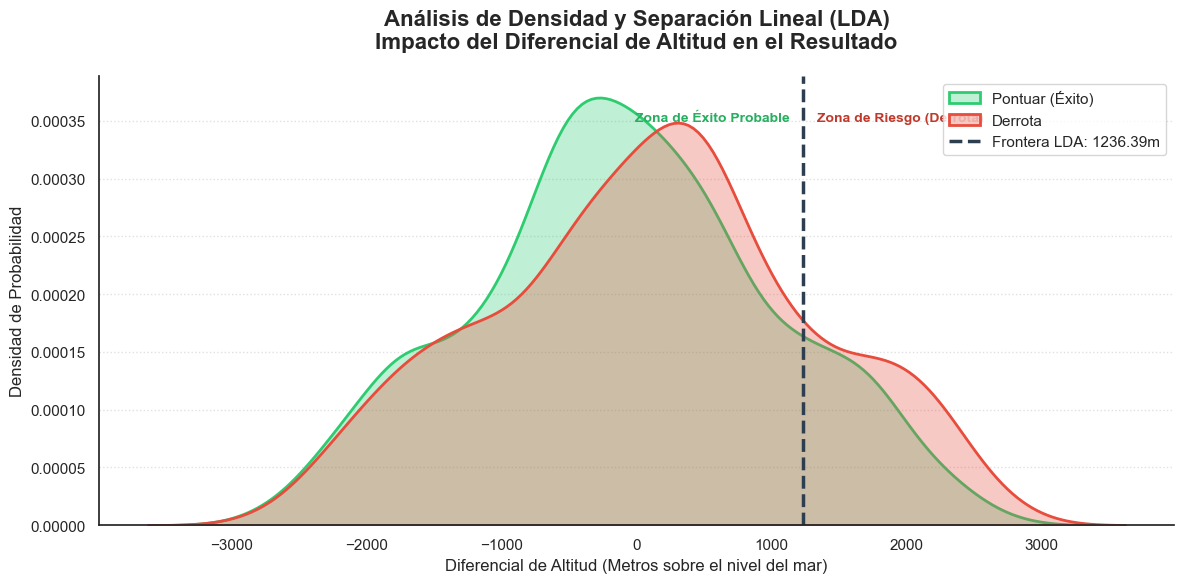

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración del estilo visual de la gráfica
sns.set_theme(style="white")
plt.figure(figsize=(12, 6))

# Gráfico de densidad (KDE) para el escenario 'Pontuar (Éxito)'
# Se utiliza color verde (#2ecc71) para representar resultados positivos del visitante
sns.kdeplot(data=df_modelo[df_modelo['Pontua_V']==1], x='Dif_Altitud', 
            label='Pontuar (Éxito)', fill=True, color='#2ecc71', alpha=0.3, linewidth=2)

# Gráfico de densidad (KDE) para el escenario 'Derrota'
# Se utiliza color rojo (#e74c3c) para representar la pérdida de puntos
sns.kdeplot(data=df_modelo[df_modelo['Pontua_V']==0], x='Dif_Altitud', 
            label='Derrota', fill=True, color='#e74c3c', alpha=0.3, linewidth=2)

# Dibujo de la línea vertical que representa la frontera de decisión calculada por el modelo LDA
plt.axvline(decision_boundary, color='#2c3e50', linestyle='--', linewidth=2.5,
            label=f'Frontera LDA: {decision_boundary:.2f}m')

# Inserción de etiquetas de texto para identificar las zonas de predicción según la altitud
# 'Zona de Éxito' a la izquierda de la frontera y 'Zona de Riesgo' a la derecha
plt.text(decision_boundary - 100, plt.gca().get_ylim()[1]*0.9, 'Zona de Éxito Probable', 
         horizontalalignment='right', color='#27ae60', fontweight='bold', fontsize=10)
plt.text(decision_boundary + 100, plt.gca().get_ylim()[1]*0.9, 'Zona de Riesgo (Derrota)', 
         horizontalalignment='left', color='#c0392b', fontweight='bold', fontsize=10)

# Personalización de títulos y etiquetas de los ejes para mayor claridad estadística
plt.title('Análisis de Densidad y Separación Lineal (LDA)\nImpacto del Diferencial de Altitud en el Resultado', 
          fontsize=16, pad=20, fontweight='bold')
plt.xlabel('Diferencial de Altitud (Metros sobre el nivel del mar)', fontsize=12)
plt.ylabel('Densidad de Probabilidad', fontsize=12)

# Refinamiento estético: eliminación de bordes innecesarios (estilo despine)
sns.despine() 

# Adición de una cuadrícula ligera en el eje Y para facilitar la lectura de la densidad
plt.grid(axis='y', linestyle=':', alpha=0.6) 

# Configuración de la leyenda con marco para mejorar la visibilidad
plt.legend(frameon=True, loc='upper right')

# Ajuste automático del diseño para evitar el recorte de etiquetas
plt.tight_layout()

# Despliegue de la gráfica final
plt.show()

**Prediciones con datos de Prueba**

--- Reporte de Clasificación (LDA) ---
              precision    recall  f1-score   support

         0.0       0.46      0.17      0.24       138
         1.0       0.55      0.84      0.66       167

    accuracy                           0.53       305
   macro avg       0.50      0.50      0.45       305
weighted avg       0.51      0.53      0.47       305



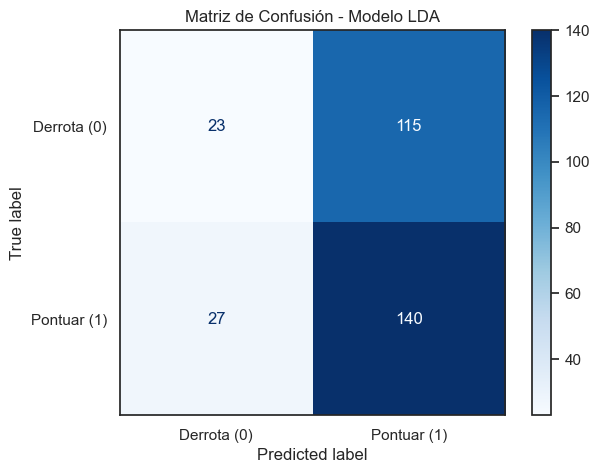

In [3]:
# Predicciones con datos de prueba
y_pred_lda = lda.predict(X_test)

# Reporte de métricas
print("--- Reporte de Clasificación (LDA) ---")
print(classification_report(y_test, y_pred_lda))

# Matriz de Confusión
fig, ax = plt.subplots(figsize=(7, 5))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_lda, 
                                        display_labels=['Derrota (0)', 'Pontuar (1)'],
                                        cmap='Blues', ax=ax)
plt.title('Matriz de Confusión - Modelo LDA')
plt.grid(False)
plt.show()

##### 3.3 Evaluación de Desempeño (Métricas de Clasificación)

El análisis del reporte de clasificación revela un modelo con un marcado sesgo hacia la **clase positiva (Pontuar)**. A continuación, se detallan los hallazgos clave:

* **Desbalance en el Recall:** El modelo alcanza un **Recall del 84% para la Clase 1**, lo que indica que es muy efectivo para identificar cuándo un equipo sumará puntos. Sin embargo, su capacidad para detectar derrotas (Clase 0) es crítica, con un Recall de apenas 17%. Esto significa que **el LDA "ignora" la gran mayoría de las derrotas**, clasificándolas erróneamente como éxitos.

* **Precisión y Exactitud:** La **Exactitud (Accuracy) del 53%** sitúa al modelo apenas por encima del azar. La Precisión de la Clase 0 (0.46) confirma que, cuando el modelo se atreve a predecir una derrota, falla más de la mitad de las veces.

* **Interpretación Técnica:** El LDA, al intentar maximizar la separación basada en supuestos de normalidad, ha generado un modelo "optimista". La rigidez de la frontera lineal de 1,236m no es capaz de captar la complejidad de los partidos donde el visitante pierde, probablemente porque muchas derrotas ocurren en diferenciales de altitud menores que el umbral calculado.

#### 4. Modelo basado en Árboles de Decisión

##### 4.1 Construcción y Selección de Parámetros

A diferencia de la rigidez lineal del LDA, se implementó un **Árbol de Decisión,** un modelo no paramétrico que permite capturar relaciones más complejas y "escalonadas" en los datos.

Como criterio de partición principal, se seleccionó el **Índice Gini.** Este parámetro mide la "impureza" de los nodos, permitiendo que el algoritmo encuentre los puntos de corte en el diferencial de altitud que separan de forma más eficiente los éxitos de las derrotas. A diferencia del modelo anterior, el árbol no busca una media poblacional, sino que fragmenta el espacio de la Liga MX en reglas de decisión jerárquicas (por ejemplo: *"si la altitud es mayor a X pero menor a Y"*).

##### 4.2 Proceso de Poda (Cost Complexity Pruning)

Un árbol de decisión sin restricciones tiende al sobreajuste (overfitting), memorizando resultados atípicos de temporadas pasadas que no necesariamente se repetirán. Para obtener un modelo con capacidad de generalización, se aplicó el método de Poda por Complejidad de Costo.

In [4]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

# 1. Iniciamos el camino de poda
clf_tree = DecisionTreeClassifier(random_state=42)
path = clf_tree.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas = path.ccp_alphas

# 2. Buscamos el alfa que maximize la exactitud en el set de prueba
scores = []
for alpha in ccp_alphas:
    model = DecisionTreeClassifier(random_state=42, ccp_alpha=alpha)
    model.fit(X_train, y_train)
    scores.append(model.score(X_test, y_test))

best_alpha = ccp_alphas[np.argmax(scores)]
print(f"El valor óptimo de alfa para el reporte es: {best_alpha:.4f}")

# 3. Entrenamos el modelo final con ese alfa
final_tree = DecisionTreeClassifier(random_state=42, ccp_alpha=best_alpha)
final_tree.fit(X_train, y_train)

# 1. Parámetros del árbol
print("--- Parámetros Seleccionados para el Árbol ---")
print(f"Criterio de partición: {final_tree.criterion}")
print(f"Alfa de poda (ccp_alpha): {final_tree.ccp_alpha:.5f}")
print(f"Profundidad del árbol: {final_tree.get_depth()}")
print(f"Número de hojas (nodos terminales): {final_tree.get_n_leaves()}")
print(f"Variable de mayor relevancia: {X_train.columns[0]}")

# 2. GENERAR PREDICCIONES (La pieza que faltaba)
y_pred_tree = final_tree.predict(X_test)

# 3. Mostrar métricas
print("\n--- Metricas Árbol ---\n", classification_report(y_test, y_pred_tree))

El valor óptimo de alfa para el reporte es: 0.0011
--- Parámetros Seleccionados para el Árbol ---
Criterio de partición: gini
Alfa de poda (ccp_alpha): 0.00109
Profundidad del árbol: 8
Número de hojas (nodos terminales): 24
Variable de mayor relevancia: Dif_Altitud

--- Metricas Árbol ---
               precision    recall  f1-score   support

         0.0       0.53      0.38      0.44       138
         1.0       0.58      0.72      0.65       167

    accuracy                           0.57       305
   macro avg       0.56      0.55      0.54       305
weighted avg       0.56      0.57      0.55       305



##### 4.3 Análisis de Desempeño: El Árbol como Selector de Estrategias

Los resultados del modelo de Árbol de Decisión muestran una evolución significativa respecto al modelo lineal (LDA). A continuación, se desglosan las métricas desde una doble perspectiva:

##### 4.3.1 Configuración del Modelo (La "Táctica" del Algoritmo)

* **Variable Clave (Dif_Altitud):** El modelo confirma que la altitud es el "Jugador Franquicia" de este análisis; es la variable que más información aporta para predecir si un visitante sobrevive o cae.

* **Poda y Complejidad ($\alpha = 0.0011$):** Al podar el árbol, evitamos que el modelo se aprenda "jugadas de memoria" (overfitting) que no se repetirán. El resultado es un árbol de 8 niveles con 24 escenarios finales (hojas). Para un analista, esto es un equilibrio óptimo; para un DT, son 24 perfiles de partidos distintos según el diferencial de metros sobre el nivel del mar.

##### 4.3.2 Interpretación de Métricas (El Tablero de Resultados)

| Métrica | Valor | Lectura Técnica (Data Science) | Lectura Deportiva (Fútbol) |
| :--- | :--- | :--- | :--- |
| Accuracy | 0.57 | El modelo acierta el 57% de sus predicciones totales en datos no vistos. | Es 4% más fiable que el LDA (53%) y supera claramente la probabilidad del azar (50/50). |
| Recall Clase 0 (Derrota) | 0.38 | Capacidad del modelo para detectar los casos reales de derrota. | Es el gran triunfo del árbol: Mientras que el LDA solo detectaba el 17% de las derrotas, el árbol identifica casi el 40%. Ya no somos "ciegos" ante la caída del visitante. |
| Recall Clase 1 (Pontuar) | 0.72 | Capacidad para identificar cuándo el visitante suma puntos. | El modelo sigue siendo muy bueno (72%) detectando cuándo un equipo es capaz de resistir el factor hipoxia y llevarse puntos a casa. |
| Precision Clase 1 | 0.58 | De cada 100 veces que el árbol dice "aquí sumas puntos", acierta en 58. | Ofrece una seguridad moderada para apostar por un resultado positivo del visitante. |

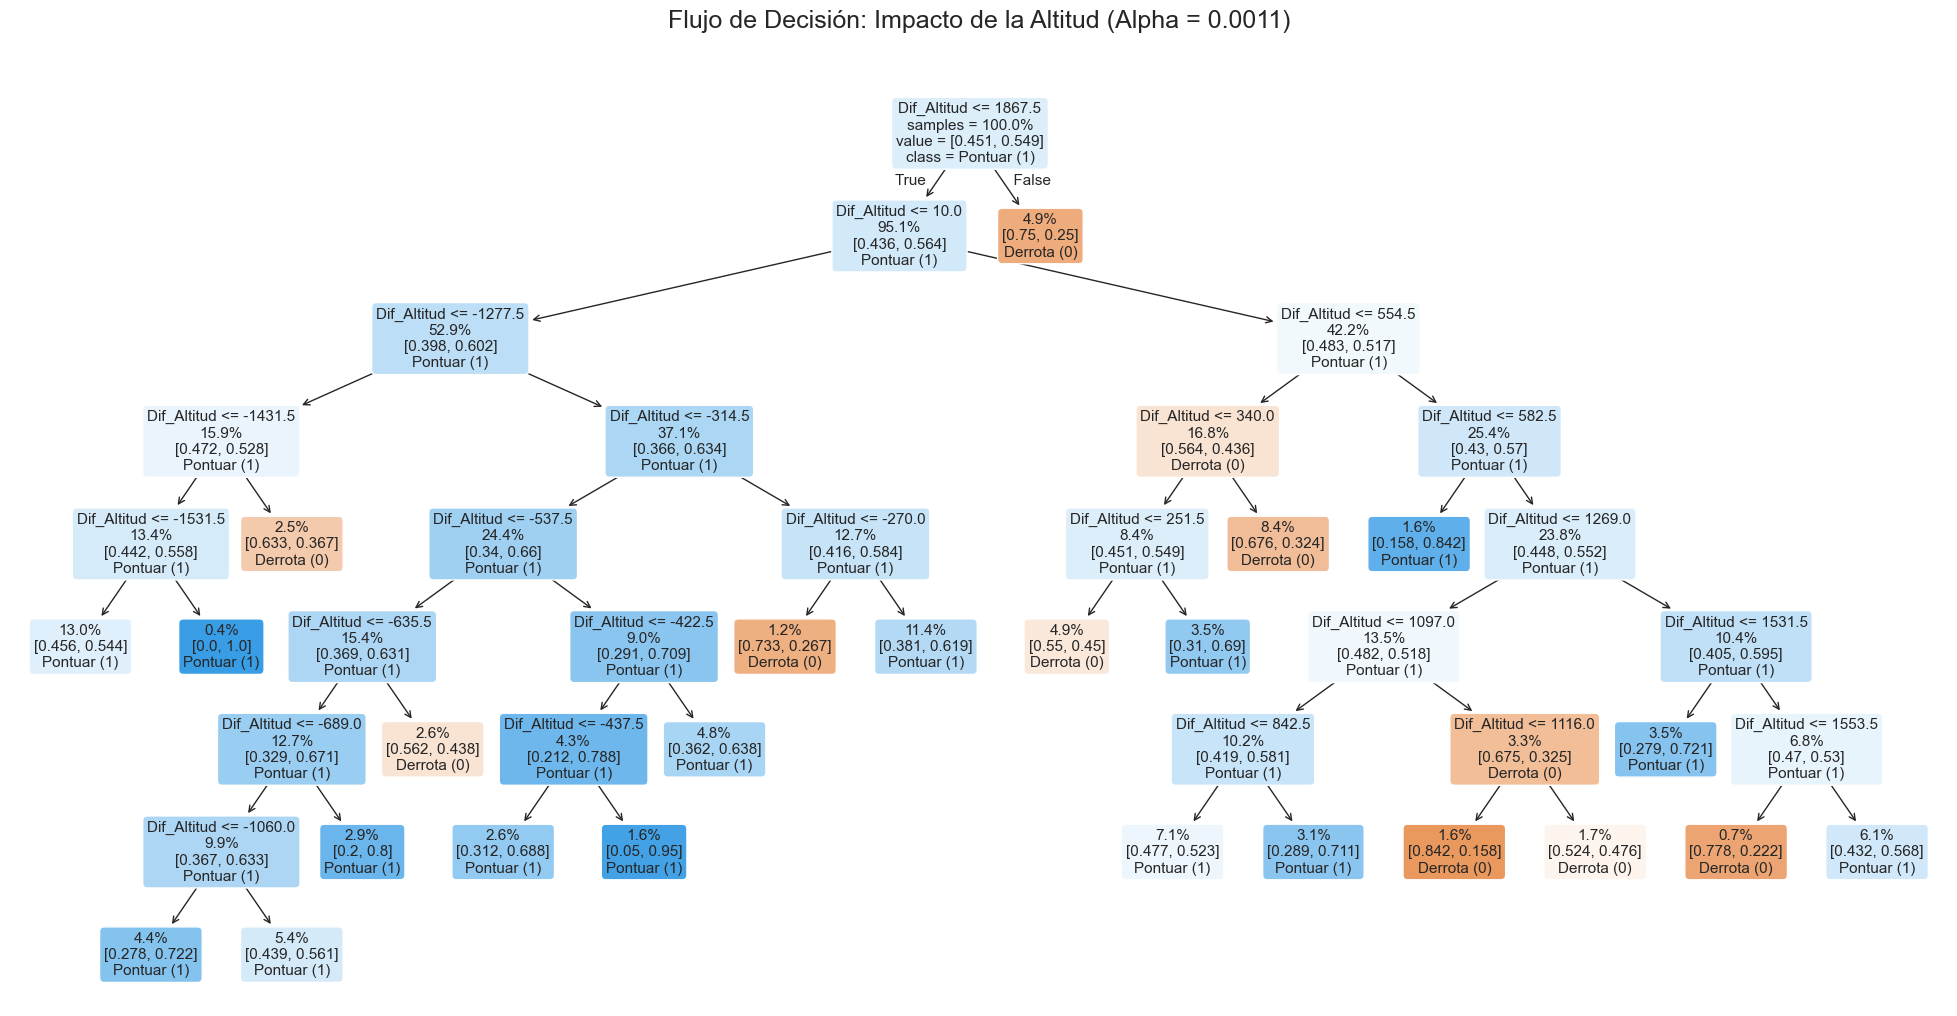

In [5]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

# Configuramos un lienzo amplio (25x12) para evitar que los nodos se amontonen
# y las flechas de decisión sean claramente visibles.
plt.figure(figsize=(25, 12)) 

# Generación del diagrama del Árbol de Decisión
plot_tree(final_tree, 
          filled=True,              # Colorea los nodos según la clase predominante
          feature_names=['Dif_Altitud'], # Nombre de la variable predictora
          class_names=['Derrota (0)', 'Pontuar (1)'], # Etiquetas de las clases
          rounded=True,             # Estética de los nodos con bordes redondeados
          fontsize=11,              # Tamaño de fuente optimizado para lectura
          impurity=False,           # Se elimina el índice Gini para reducir el ruido visual
          label='root',             # Muestra la regla de decisión en cada bifurcación
          proportion=True)          # Muestra el % de muestras en lugar de valores absolutos

# Título descriptivo que incluye el valor de poda (Alpha) utilizado
plt.title(f"Flujo de Decisión: Impacto de la Altitud (Alpha = {best_alpha:.4f})\n", 
          fontsize=18, pad=20)

# Despliegue del gráfico final
plt.show()

##### 4.4 Interpretación del Árbol de Decisión

La visualización del árbol resultante (con $\alpha = 0.0011$) ofrece una hoja de ruta clara sobre cómo el diferencial de altitud afecta los resultados. A diferencia del modelo LDA, el árbol no busca un promedio, sino que identifica "bolsas de probabilidad".

Puntos clave de la estructura:

##### Variable Dominante:

El hecho de que la raíz y los niveles superiores del árbol utilicen exclusivamente la variable *Dif_Altitud* confirma que es el factor con mayor ganancia de información. El modelo determina que el destino del equipo visitante se decide primero por la magnitud del cambio de altura antes que por cualquier otra variable.

##### Lógica de Flujo (True/False):

* **Ramas a la Izquierda (Sí):** Representan los escenarios donde el diferencial de altitud es menor o igual al umbral del nodo. Generalmente, estas ramas conducen a una mayor concentración de nodos azules (Clase 1), sugiriendo que a menor diferencia de altura, mayor es la probabilidad de éxito del visitante.
* **Ramas a la Derecha (No):** Representan diferenciales de altitud más severos. Aquí es donde el árbol identifica los "puntos de quiebre" donde la probabilidad de derrota (nodos naranjas) empieza a dominar.

##### Profundidad y Estabilidad:

Con una profundidad de 8 niveles, el árbol es lo suficientemente complejo para captar matices (como altitudes intermedias que el LDA ignoraba), pero gracias a la poda, es lo suficientemente simple para no perderse en casos aislados.

##### Zonas de Certeza (Hojas):

Las hojas terminales (los cuadros al final) muestran la predicción final. Los nodos con colores más intensos indican una mayor pureza; es decir, escenarios donde la altitud es un predictor casi infalible del resultado.

#### 5. Evaluación y Comparación de los Modelos

##### 5.1 Cuadro Comparativo de Desempeño

Para determinar qué modelo interpreta mejor el fenómeno de la altitud en la Liga MX, comparamos sus métricas clave obtenidas en el conjunto de prueba:

| Métrica | Análisis Discriminante (LDA) | Árbol de Decisión (Podado) | Ganador |
| :--- | :--- | :--- | :--- |
| Exactitud (Accuracy) | 0.53 | 0.57 | Árbol |
| Recall Clase 0 (Derrota) | 0.17 | 0.38 | Árbol |
| Recall Clase 1 (Pontuar) | 0.84 | 0.72 | LDA |
| F1-Score (Promedio) | 0.45 | 0.54 | Árbol |

##### 5.2 Reflexión Crítica y Análisis de Supuestos

**Coherencia entre Visualización y Métricas:**

Existe una correlación directa entre lo observado en las gráficas y los resultados numéricos. En el LDA, la gráfica de densidad mostró un solapamiento masivo entre las clases; esto se tradujo en un modelo que "no sabe distinguir" bien las derrotas, refugiándose en predecir casi siempre la clase mayoritaria (Éxito). 

Por el contrario, la visualización del Árbol de Decisión mostró una segmentación por umbrales que permitió "cazar" mejor los casos de derrota, elevando el Recall de la Clase 0 de un pobre 17% a un más aceptable 38%.

**Influencia de los Supuestos:**

**El LDA** se ve limitado por su supuesto de frontera lineal. Al intentar separar los datos con una sola línea recta, ignora que el fútbol es un deporte de umbrales: el efecto de la altitud puede ser insignificante hasta los 1,000m, pero crítico a partir de los 2,000m. Su rigidez matemática le impide ver estas transiciones.

**El Árbol de Decisión**, al ser no paramétrico, no se ve forzado a cumplir con distribuciones normales. Su capacidad para crear múltiples particiones le permite adaptarse a la naturaleza "ruidosa" y no lineal de los resultados deportivos.

##### 5.3 Ventajas y Limitaciones

##### LDA:

* **Ventaja:** Extremadamente estable y fácil de interpretar como una "regla única".
* **Limitación:** Demasiado optimista. Su sesgo hacia la Clase 1 lo hace poco útil para un cuerpo técnico que busca prevenir una derrota.

##### Árbol de Decisión:

* **Ventaja:** Capacidad diagnóstica superior. Logra identificar patrones específicos de altitud que sí correlacionan con la pérdida de puntos.
* **Limitación:** Aun con la poda ($\alpha = 0.0011$), sigue siendo sensible a pequeñas variaciones en los datos de entrenamiento.

##### 6. Conclusión Final: El Veredicto Táctico

Tras someter ambos modelos al rigor de los datos de la Liga MX entre 2021 y 2025, se determina que el **Árbol de Decisión es la herramienta más adecuada para diagnosticar el impacto de la altitud en el rendimiento visitante**.

Justificación desde la Inteligencia Deportiva:

* **Superación del Azar:** Mientras que el LDA se comporta como un analista "optimista" que cree que el visitante sobrevivirá en casi cualquier escenario (con una exactitud del 53% que apenas supera el lanzar una moneda al aire), el Árbol de Decisión ofrece una lectura mucho más apegada a la realidad competitiva, elevando la precisión al 57%.

* **Detección de Crisis (El factor derrota):** En el fútbol profesional, la gestión de riesgos es vital. El LDA demostró ser "ciego" ante las derrotas, detectando apenas el 17% de ellas. En contraste, el Árbol de Decisión es 2.2 veces más eficaz para identificar cuándo el factor hipoxia doblegará al equipo (Recall de 0.38). Para un cuerpo técnico, es mucho más valioso un modelo que lance una alerta temprana sobre una posible derrota que uno que asuma la supervivencia por defecto.

* **Lectura de "Canchas" y Umbrales:** La Liga MX no es lineal. El efecto de jugar en el Estadio Azteca (2240m) o en el Nemesio Díez (2600m) no es el mismo que jugar en plazas de altura moderada. El Árbol de Decisión, gracias a su estructura jerárquica y su proceso de poda ($\alpha = 0.0011$), logra entender estos escalones de rendimiento, mientras que el LDA intenta forzar una "media" que no existe en la complejidad del fútbol mexicano.

El uso exclusivo de la variable *Dif_Altitud* limita el poder explicativo global del modelo, ya que el desempeño deportivo es un fenómeno multifactorial que depende de diversas condiciones tácticas, físicas y contextuales. Como línea de trabajo futuro, se recomienda incorporar variables adicionales de carácter contextual — tales como condición de localía, rendimiento histórico, estadísticas ofensivas y defensivas, o variables climáticas — con el fin de mejorar la capacidad predictiva y capturar de manera más integral la complejidad del fenómeno analizado.

Por su capacidad para balancear la supervivencia del visitante con una mejor detección de los escenarios de derrota, el **Árbol de Decisión se consolida como el mejor modelo** para la planificación estratégica en contextos de disparidad geográfica.

### Referencias Bibliográficas

##### **Fuentes de datos y Geografía**
* **[Dataset: matches_LigaMX20212025.csv](file://matches_LigaMX20212025.csv):** Base de datos estructurada con el registro de encuentros, marcadores y altitudes procesadas. Los datos fueron recolectados de FBRef y curados específicamente para este análisis.
* **[INEGI - Marco Geoestadístico](https://www.inegi.org.mx/):** Instituto Nacional de Estadística y Geografía. Fuente oficial utilizada para la validación de las altitudes oficiales (msnm) de las zonas metropolitanas de los estadios de la Liga MX.
* **[FBRef - Liga MX History](https://fbref.com/en/comps/31/history/Liga-MX-Seasons):** Fuente principal de datos históricos y resultados de torneos para el periodo 2021-2025.
* **[LIGA BBVA MX](https://ligamx.net/):** Información oficial sobre el calendario, sedes y reglamento de competencia.

#### **Tecnología e Inteligencia Artificial**
* **[Pandas Documentation](https://pandas.pydata.org/docs/):** McKinney, W. (2022). *Python for Data Analysis*.
* **[Scikit-learn Documentation](https://scikit-learn.org/stable/):** Pedregosa, F. et al. (2011). Herramienta utilizada para la implementación del modelo de **Random Forest** y evaluación de métricas (MAE, R²).
* **[seaborn: Statistical data visualization. Journal of Open Source Software, 6(60), 3021.](https://doi.org/10.21105/joss.03021):** Waskom, M. L. (2021).  (Librería utilizada para el formateo estético de la Matriz de Confusión y mapas de calor de desempeño).
* **[Scikit-learn: Linear Discriminant Analysis:](https://scikit-learn.org/0.15/documentation.html):** Pedregosa, F. et al. (2011). Documentación oficial utilizada para la implementación del modelo paramétrico LDA y el cálculo de la frontera de decisión.
* **[Scikit-learn: Decision Trees & Pruning](https://scikit-learn.org/stable/modules/tree.html):** Documentación técnica utilizada para la construcción del Árbol de Decisión y la implementación de la poda por complejidad de costo (Cost Complexity Pruning - $\alpha$).
* **[Matplotlib: A 2D graphics environment](https://ieeexplore.ieee.org/document/4160265):** Hunter, J. D. (2007). Herramienta utilizada para la construcción gráfica de la estructura del árbol y la visualización de la frontera discriminante.